#### In this notebook, I am going to use an CNN model to identify handwritten digits using the PyTorch framework. 
##### I am using the Digit recognizer data from Kaggle data.

In [5]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [7]:
## Create class for CNN model
class CNNmodel(nn.Module):

    def __init__(self):

        super(CNNmodel, self).__init__()

        #Conv layer 1
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 5, stride = 1, padding = 0)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.1)

        #Maxpool layer 1
        self.maxpool1 = nn.MaxPool2d(kernel_size = 2)

        #Conv layer 2
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 5, stride = 1, padding = 0)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.1)

        #Maxpool layer 2
        self.maxpool2 = nn.MaxPool2d(kernel_size = 2)

        #Fully connected layers

        self.fc1 = nn.Linear(32*4*4,120)
        self.fc2 = nn.Linear(120,10)

    def forward(self, x):

        out = self.conv1(x)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.maxpool1(out)

        out = self.conv2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        out = self.maxpool2(out)

        out = out.view(out.size(0), -1)

        out = self.fc1(out)
        out = self.fc2(out)

        return out

In [9]:
## Digit recognizer dataset from Kaggle
train = pd.read_csv(r"digit-recognizer/train.csv",dtype = np.float32)
valid = pd.read_csv(r"digit-recognizer/test.csv",dtype = np.float32)

In [11]:
## number of classes
len(train.label.unique())

10

In [13]:
## Splitting to training and test data
train_features = train.loc[:,train.columns!= 'label'].values/255
train_labels = train.label.values

features_train, features_test, targets_train, targets_test = train_test_split(train_features, train_labels,
                                                                              test_size = 0.2, random_state = 42)

In [15]:
## Converting Training and test data to Tensors for Pytorch
featuresTrain = torch.from_numpy(features_train)
targetsTrain = torch.from_numpy(targets_train).type(torch.LongTensor)

featuresTest = torch.from_numpy(features_test)
targetsTest = torch.from_numpy(targets_test).type(torch.LongTensor)

train = torch.utils.data.TensorDataset(featuresTrain, targetsTrain)
test = torch.utils.data.TensorDataset(featuresTest, targetsTest)

In [17]:
## Defining batch size and number of iterations
batch_size = 100
num_iters = 7500
num_epochs = num_iters / (len(train_features) / batch_size)
num_epochs = int(num_epochs)

train_loader = DataLoader(train, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)

## Use GPU for training the model
device = torch.device('cuda')

model = CNNmodel().to(device)

loss = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

In [19]:
## Train and test the model
count = 0
train_loss_list = []
valid_loss_list = []
iteration_list = []
accuracy_list = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        train = images.to(device).view(100, 1, 28, 28)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(train)

        # Calculate softmax and ross entropy loss
        train_loss = loss(outputs, labels)

        # Calculating gradients
        train_loss.backward()

        # Update parameters
        optimizer.step()

        count += 1

        if count % 50 == 0:
            # Calculate Accuracy
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                test = images.to(device).view(100, 1, 28, 28)

                # Forward propagation
                outputs = model(test)

                valid_loss = loss(outputs, labels.to(device))

                # Get predictions from the maximum value
                predicted = torch.max(outputs.data, 1)[1]

                # Total number of labels
                total += len(labels.to(device))

                correct += (predicted == labels.to(device)).sum()

            accuracy = 100 * correct / float(total)

            # store loss and iteration
            train_loss_list.append(train_loss.data.item())
            valid_loss_list.append(valid_loss.data.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        if count % 500 == 0:
            # Print Loss
            print('Iteration: {}  Training Loss: {}  Validation Loss: {}  Accuracy: {} %'.format(count, train_loss.data,
                                                                                                 valid_loss.data,
                                                                                                 accuracy))

Iteration: 500  Training Loss: 0.11105027049779892  Validation Loss: 0.31224459409713745  Accuracy: 96.30952453613281 %
Iteration: 1000  Training Loss: 0.05402132868766785  Validation Loss: 0.1897190511226654  Accuracy: 97.64285278320312 %
Iteration: 1500  Training Loss: 0.04632849618792534  Validation Loss: 0.20072728395462036  Accuracy: 97.64285278320312 %
Iteration: 2000  Training Loss: 0.017808988690376282  Validation Loss: 0.09669093787670135  Accuracy: 98.13095092773438 %
Iteration: 2500  Training Loss: 0.03001120314002037  Validation Loss: 0.12732061743736267  Accuracy: 98.20237731933594 %
Iteration: 3000  Training Loss: 0.041144900023937225  Validation Loss: 0.11151960492134094  Accuracy: 98.4047622680664 %
Iteration: 3500  Training Loss: 0.022517874836921692  Validation Loss: 0.11708814650774002  Accuracy: 98.51190185546875 %
Iteration: 4000  Training Loss: 0.0039591616950929165  Validation Loss: 0.12070142477750778  Accuracy: 98.47618865966797 %
Iteration: 4500  Training Loss

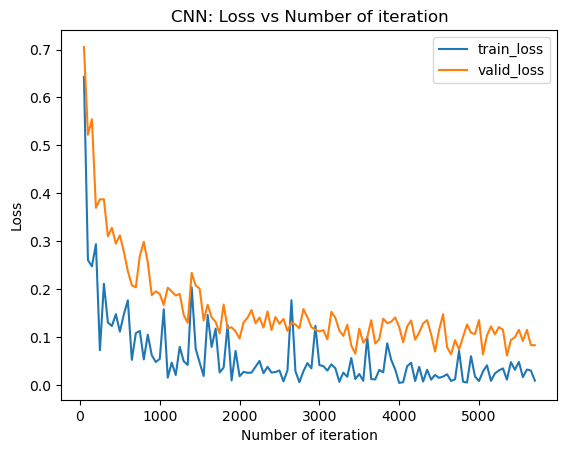

In [25]:
# visualization loss
plt.plot(iteration_list,train_loss_list, label = 'train_loss')
plt.plot(iteration_list,valid_loss_list, label = 'valid_loss')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.legend(loc="upper right")
plt.show()